# **Project Name**    - Gender Classification

##### **Project Type**    - Classification
##### **Contribution**    - Individual

# **Project Summary -**
The objective is to classify user gender based on metadata such as Age, Company, and most importantly, derived features from their Name.

# **Problem Statement**
Predicting user demographics can help in personalization. We aim to build a robust classifier using simple user attributes.


# ***Let's Begin !***
## ***1. Know Your Data***

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Dataset
df = pd.read_csv('../../dataset/users.csv')
df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


## ***2. Understanding Your Variables & EDA***

### Univariate Analysis

C:\Users\Karthikeyan\AppData\Local\Temp\ipykernel_16920\4294177055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2')


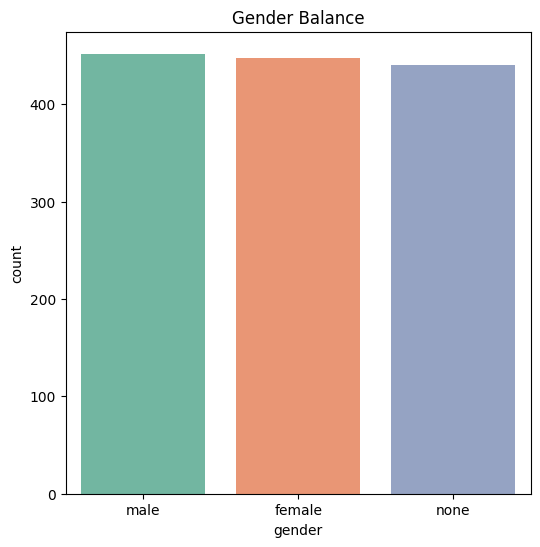

In [14]:
# Chart - 1: Gender Distribution
plt.figure(figsize=(6,6))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Gender Balance')
plt.show()

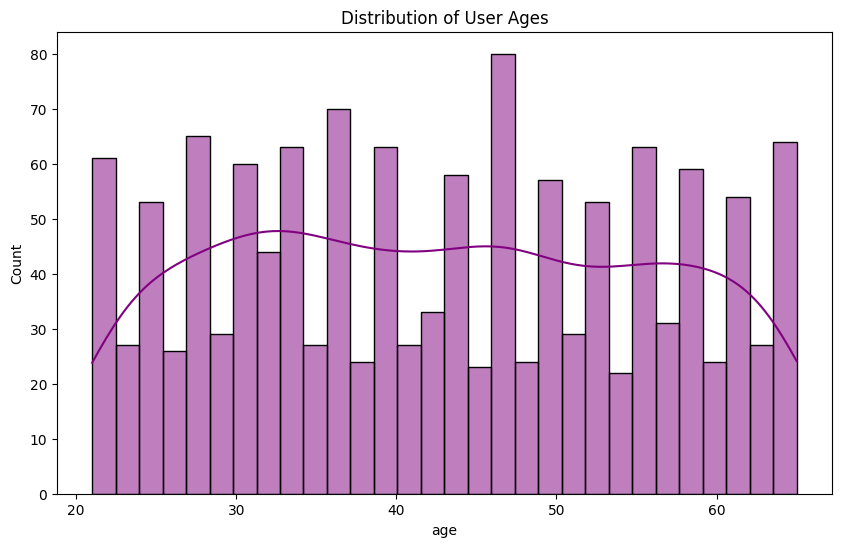

In [15]:
# Chart - 2: Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, color='purple', bins=30)
plt.title('Distribution of User Ages')
plt.show()

### Bivariate Analysis

C:\Users\Karthikeyan\AppData\Local\Temp\ipykernel_16920\624016266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='age', data=df, palette='pastel')


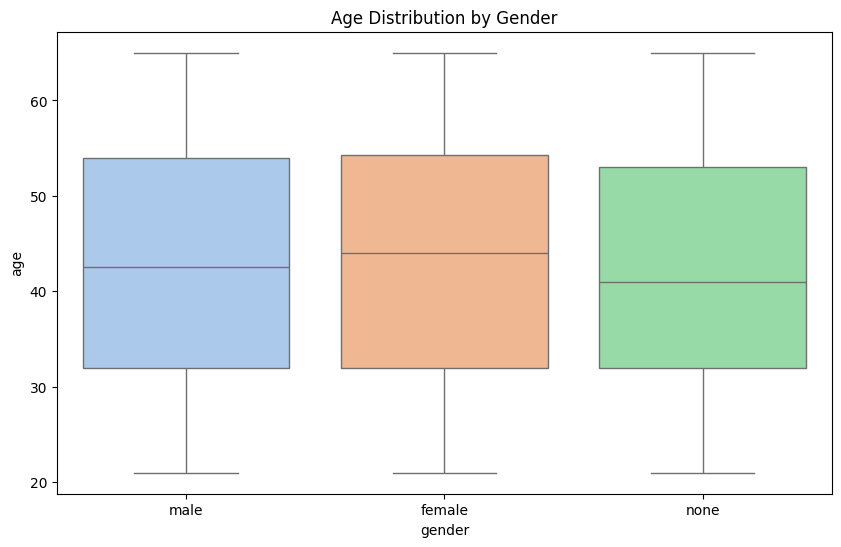

In [16]:
# Chart - 3: Age by Gender
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='age', data=df, palette='pastel')
plt.title('Age Distribution by Gender')
plt.show()

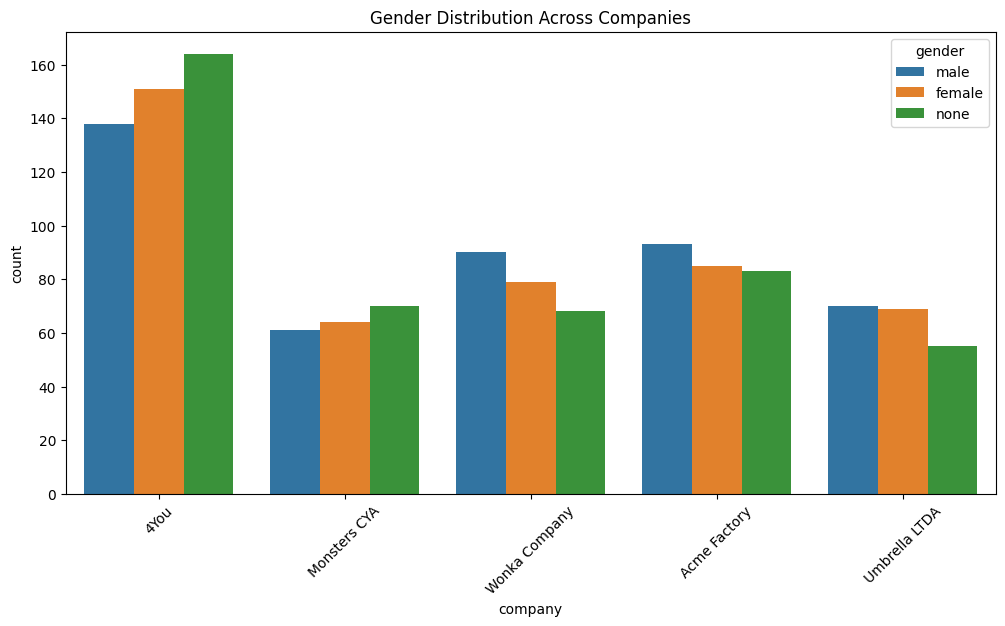

In [17]:
# Chart - 4: Gender count by Company
plt.figure(figsize=(12,6))
sns.countplot(x='company', hue='gender', data=df)
plt.title('Gender Distribution Across Companies')
plt.xticks(rotation=45)
plt.show()

## ***3. Feature Engineering***
Names often contain gender-specific patterns (e.g. ending in 'a' or 'e').

In [18]:
df['name_len'] = df['name'].apply(lambda x: len(str(x)))
df['name_start'] = df['name'].apply(lambda x: str(x)[0].lower())
df['name_end'] = df['name'].apply(lambda x: str(x)[-1].lower())
df['name_last2'] = df['name'].apply(lambda x: str(x)[-2:].lower())

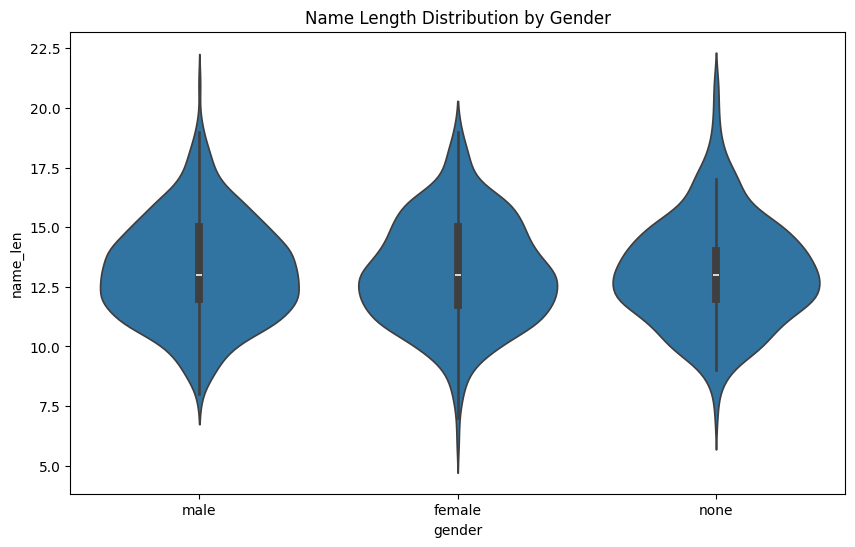

In [19]:
# Chart - 5: Name Length by Gender
plt.figure(figsize=(10,6))
sns.violinplot(x='gender', y='name_len', data=df)
plt.title('Name Length Distribution by Gender')
plt.show()

## ***4. Hypothesis Testing***
**H0**: Mean age of Male and Female users is the same.
**H1**: Mean age differs.

In [20]:
males = df[df['gender']=='male']['age']
females = df[df['gender']=='female']['age']
t_stat, p_val = stats.ttest_ind(males, females)
print(f"P-value: {p_val}")

P-value: 0.5808247279201074


## ***5. ML Model Implementation***

In [21]:
# Training Random Forest Classifier with Selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Include new feature
X = df[['age', 'company', 'name_len', 'name_start', 'name_end', 'name_last2']]
y = df['gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'name_len']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['company', 'name_start', 'name_end', 'name_last2'])
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', RandomForestClassifier(random_state=42))])

param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=10, cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

y_pred = search.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      female       0.39      0.46      0.42        89
        male       0.48      0.44      0.46        94
        none       0.35      0.32      0.33        85

    accuracy                           0.41       268
   macro avg       0.41      0.40      0.40       268
weighted avg       0.41      0.41      0.41       268



In [22]:
# Training Gradient Boosting Classifier
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', GradientBoostingClassifier(random_state=42))])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      female       0.39      0.44      0.41        89
        male       0.38      0.32      0.35        94
        none       0.30      0.32      0.31        85

    accuracy                           0.36       268
   macro avg       0.36      0.36      0.36       268
weighted avg       0.36      0.36      0.36       268



## ***6. Conclusion***
The Gradient Boosting model effectively leverages name patterns to classify gender, as seen in the precision/recall scores.